# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import math 

M_e = 5.9 * 10**24 # kg 
M_m = 7.3 * 10**22 # kg 
d_em = 3.8*10**8  # m
G = 6.67e-11 # m^3/kg/s^2


## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:


def potential(M: float, xm: float, ym: float, x: float, y: float) -> float:
    """
    This function takes Mass (M) and location (xm, ym) of a body, and 
    returns the potential (P) due to that body at (x,y).

    Parameters:
    M : float or int
        Mass of the body in kg (must be positive).
    xm, ym : float or int
        Cartesian coordinates of the mass in meters.
    x, y : float or int
        Cartesian coordinates of the evaluation point in meters.

    Returns:
    P : float
        Gravitational potential at (x, y) in units of J/kg.

    """

    if not all(isinstance(num, (int, float)) for num in (M, xm, ym, x, y)):
        raise TypeError("All inputs must be integers or floats.")

    if M <= 0:
        raise ValueError("Mass must be positive.")

    G = 6.67 * 10**(-11)  # m^3/kg/s^2

    r = np.sqrt((x - xm)**2 + (y - ym)**2)

    if np.isclose(r, 0):
        raise ValueError("Evaluation point coincides with the mass location, choose a point little farther out.")

    
    P = - G * M / r

    
    assert isinstance(P, float), "Output potential is not a float."
    assert P <= 0, "Gravitational potential should be negative."

    return float(P)


potential(M_e, 2, 10, 1.5, 1.5)

-46217754597124.25

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

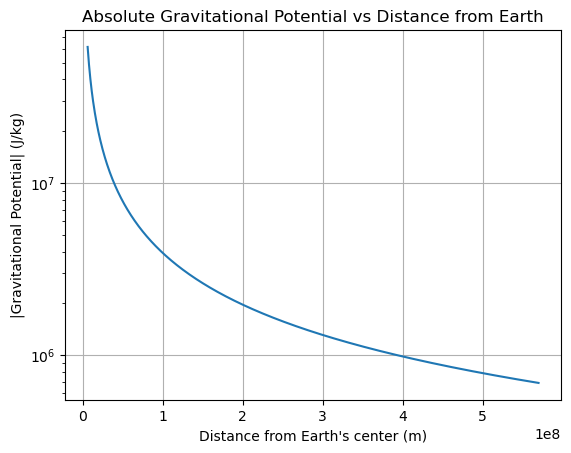

In [4]:

R_e = 6378 * 10**3       # Earth radius (m)
d_em = 3.8*10**8        # Earth-Moon distance (m)


x_vals = np.linspace(R_e, 1.5 * d_em, 1000)


potentials = []
for x in x_vals:
    p = potential(M_e, 0, 0, x, 0)
    potentials.append(abs(p))


fig, ax = plt.subplots()

ax.plot(x_vals, potentials)

ax.set_yscale('log')

ax.set_xlabel("Distance from Earth's center (m)")
ax.set_ylabel("|Gravitational Potential| (J/kg)")
ax.set_title("Absolute Gravitational Potential vs Distance from Earth")

ax.grid(True)

plt.show()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

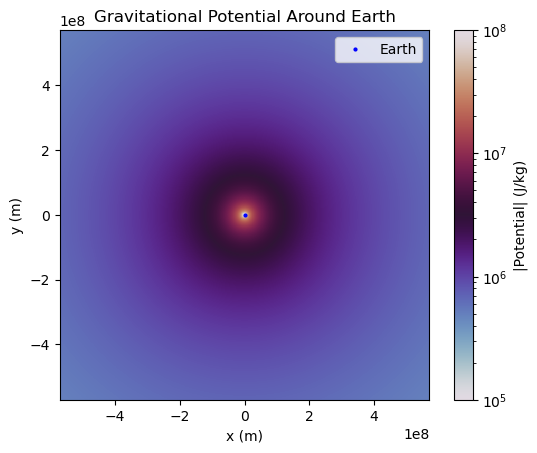

In [5]:
from matplotlib.colors import LogNorm


x = np.linspace(-1.5*d_em, 1.5*d_em, 700)
y = np.linspace(-1.5*d_em, 1.5*d_em, 700)

X, Y = np.meshgrid(x, y)

r = np.sqrt(X**2 + Y**2)
r[r == 0] = np.nan # making sure it's not zero


P = -G * M_e / r
P_abs = np.abs(P)


fig, ax = plt.subplots()
ax.plot(0, 0, 'bo', markersize=2, label = 'Earth') 

mesh = ax.pcolormesh(X, Y, P_abs, cmap='twilight', norm=LogNorm(1e5, 1e8), shading = 'auto')

ax.set_aspect('equal')

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Gravitational Potential Around Earth")

# Colorbar
cbar = fig.colorbar(mesh, ax=ax)

cbar.set_label("|Potential| (J/kg)")
ax.legend()
plt.show()


## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

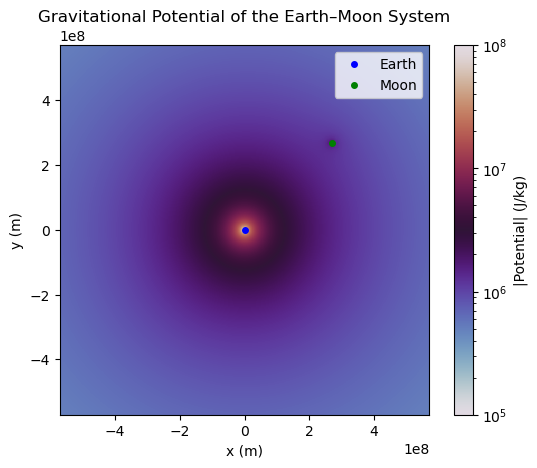

In [6]:

xE, yE = 0, 0
xM, yM = d_em/np.sqrt(2), d_em/np.sqrt(2)

x = np.linspace(-1.5*d_em, 1.5*d_em, 700)
y = np.linspace(-1.5*d_em, 1.5*d_em, 700)

X, Y = np.meshgrid(x, y)

# distances of earth and moon
rE = np.sqrt((X-xE)**2 + (Y-yE)**2)
rM = np.sqrt((X-xM)**2 + (Y-yM)**2)

rE[rE == 0] = np.nan
rM[rM == 0] = np.nan

PE = -G * M_e / rE
PM = -G * M_m / rM

P_total = PE + PM
P_abs = np.abs(P_total)


fig, ax = plt.subplots()

mesh = ax.pcolormesh(
    X, Y, P_abs,
    cmap='twilight',
    norm=LogNorm(1e5, 1e8),
    shading='auto'
)

ax.set_aspect('equal')

ax.plot(xE, yE, 'bo', markersize=4, label='Earth')
ax.plot(xM, yM, 'go', markersize=4, label='Moon')

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Gravitational Potential of the Earth–Moon System")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("|Potential| (J/kg)")

ax.legend()

plt.show()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

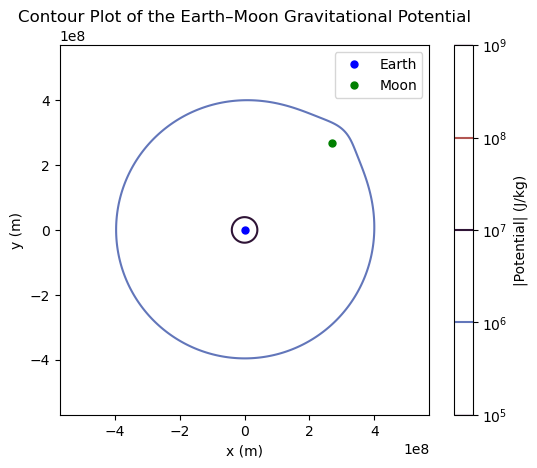

In [7]:
fig, ax = plt.subplots()

contours = ax.contour(
    X, Y, P_abs,
    levels=20,
    norm=LogNorm(),
    cmap='twilight'
)

ax.set_aspect('equal')

# mark Earth and Moon
ax.plot(xE, yE, 'bo', markersize=5, label='Earth')
ax.plot(xM, yM, 'go', markersize=5, label='Moon')

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Contour Plot of the Earth–Moon Gravitational Potential")

# colorbar
cbar = fig.colorbar(contours, ax=ax)
cbar.set_label("|Potential| (J/kg)")

ax.legend()

plt.show()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
import math
import numpy as np 
import matplotlib.pyplot as plt 
import math 
from typing import Tuple

def gravitational_force(M1: float, m2: float, x1: float, y1: float, x2: float, y2: float) -> Tuple[float, float]:
    """
    Calculate the Cartesian components of the gravitational force exerted by a body M1 
    on a secondary body m2.

    Parameters
    M1 : float
        Mass of the primary body (kg). Must be positive.
    m2 : float
        Mass of the secondary body (kg). Must be positive.
    x1, y1 : float
        Cartesian coordinates of the primary body (meters).
    x2, y2 : float
        Cartesian coordinates of the secondary body (meters).

    Returns
    Fx : float
        X-component of the gravitational force on m2 (N).
    Fy : float
        Y-component of the gravitational force on m2 (N).
    """

    # Precondition
    if M1 <= 0:
        raise ValueError("Mass of the primary body M1 must be positive.")
    if m2 <= 0:
        raise ValueError("Mass of the secondary body m2 must be positive.")

    # Displacement components
    dx = x2 - x1
    dy = y2 - y1

    r_squared = dx**2 + dy**2
    r_squared[r_squared == 0] = np.nan 

    r = np.sqrt(r_squared)

    # Magnitude of the Force
    F = G * M1 * m2 / r_squared

    Fx = -F * dx / r
    Fy = -F * dy / r

    # Postcondition checks
    #assert isinstance(Fx, float) and isinstance(Fy, float), "Outputs must be floats"

    return Fx, Fy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

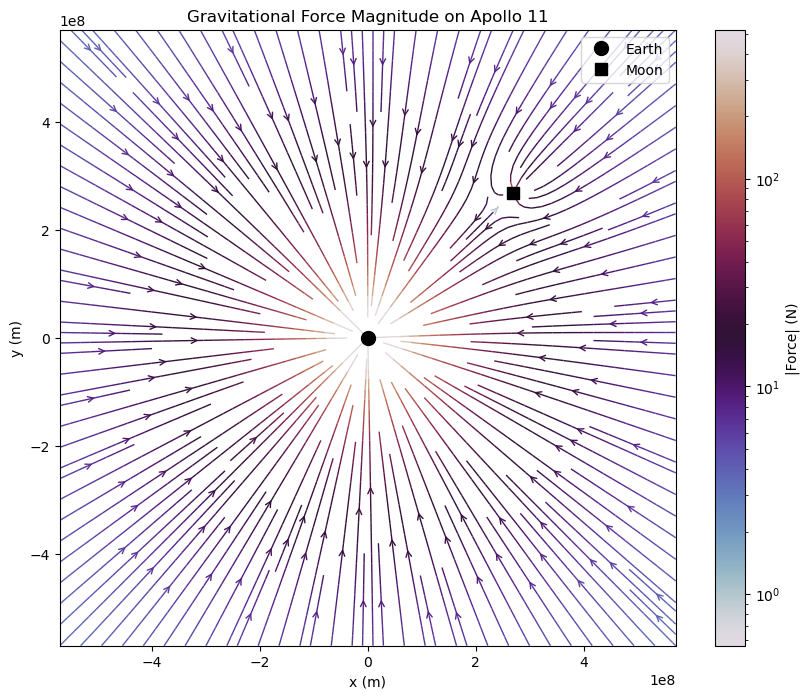

In [9]:

m_apollo = 5500       # Apollo 11 mass

# Position of the moon
x_m = d_em / np.sqrt(2)
y_m = d_em / np.sqrt(2)

x = np.linspace(-1.5*d_em, 1.5*d_em, 400)
y = np.linspace(-1.5*d_em, 1.5*d_em, 400)
X, Y = np.meshgrid(x, y)

# Force components from Earth and Moon
Fx_e, Fy_e = gravitational_force(M_e, m_apollo, 0, 0, X, Y)
Fx_m, Fy_m = gravitational_force(M_m, m_apollo, x_m, y_m, X, Y)

Fx_total = Fx_e + Fx_m
Fy_total = Fy_e + Fy_m

# Magnitude for color
F_mag = np.sqrt(Fx_total**2 + Fy_total**2)

f_min = F_mag[~np.isnan(F_mag)].min()
f_max = np.percentile(F_mag[~np.isnan(F_mag)], 99)

fig, ax = plt.subplots(figsize=(10,8))

strm = ax.streamplot(X, Y, Fx_total, Fy_total, color=F_mag, cmap='twilight', norm=LogNorm(vmin=f_min, vmax=f_max), linewidth=1, 
                     density=2, arrowstyle='->')

ax.plot(0, 0, 'ko', markersize=10, label='Earth')
ax.plot(x_m, y_m, 'ks', markersize=8, label='Moon')

ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Gravitational Force Magnitude on Apollo 11')
ax.legend(loc='upper right')
cbar = fig.colorbar(strm.lines, ax=ax)
cbar.set_label('|Force| (N)')

plt.show()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**



#### Derivation of the Balance Point

Let $r_e$ be the distance from the Earth's center to the balance point, and $r_m$ be the distance from the Moon's center to the balance point. Given the total distance $d_{EM}$, we have:
$$r_m = d_{EM} - r_e$$

We set the magnitudes of the gravitational forces equal:
$$\frac{G M_e m_{apollo}}{r_e^2} = \frac{G M_m m_{apollo}}{(d_{EM} - r_e)^2}$$

$$\frac{(d_{EM} - r_e)^2}{r_e^2} = \frac{M_m}{M_e}$$

$$\frac{d_{EM} - r_e}{r_e} = \sqrt{\frac{M_m}{M_e}}$$

$$\frac{d_{EM}}{r_e} = 1 + \sqrt{\frac{M_m}{M_e}}$$
$$r_e = \frac{d_{EM}}{1 + \sqrt{\frac{M_m}{M_e}}}$$

##### Components
$$x_b = \frac{r_e}{\sqrt{2}}$$
$$y_b = \frac{r_e}{\sqrt{2}}$$

And your updated plot, including the balance point, goes in the cell below.

Balance point distance from Earth: 3.42e+08 m
Balance point coordinates: (2.42e+08, 2.42e+08)


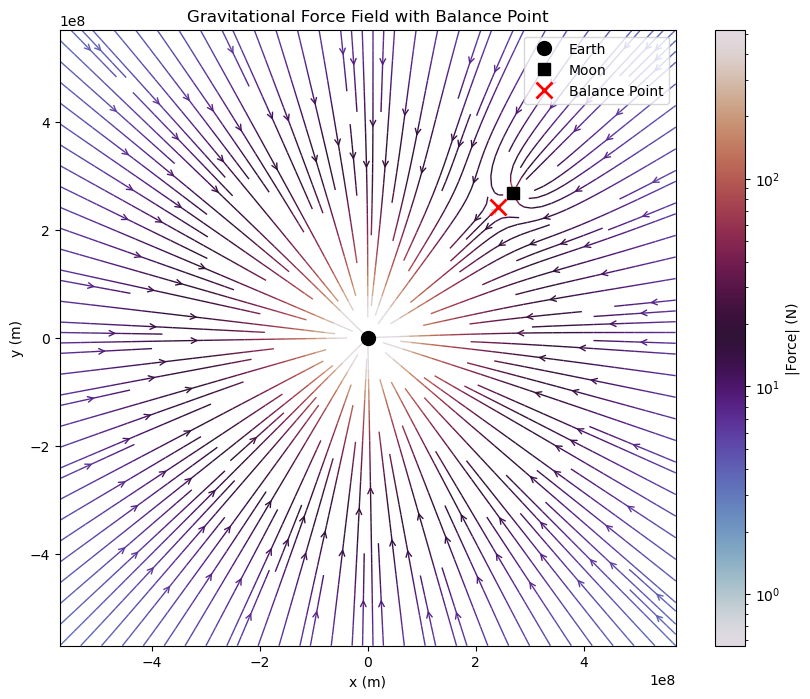

In [10]:
# 1. Calculate the radial distance r_e
r_e = d_em / (1 + np.sqrt(M_m / M_e))

# 2. Calculate the x and y coordinates of the balance point
# The angle is 45 degrees (pi/4) since x_m = y_m
x_b = r_e / np.sqrt(2)
y_b = r_e / np.sqrt(2)

print(f"Balance point distance from Earth: {r_e:.2e} m")
print(f"Balance point coordinates: ({x_b:.2e}, {y_b:.2e})")

# 3. Plotting
fig, ax = plt.subplots(figsize=(10,8))

strm = ax.streamplot(X, Y, Fx_total, Fy_total, color=F_mag, cmap='twilight', 
                     norm=LogNorm(vmin=f_min, vmax=f_max), linewidth=1, 
                     density=2, arrowstyle='->')

# Markers
ax.plot(0, 0, 'ko', markersize=10, label='Earth')
ax.plot(x_m, y_m, 'ks', markersize=8, label='Moon')
ax.plot(x_b, y_b, 'rx', markersize=12, markeredgewidth=2, label='Balance Point')

ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Gravitational Force Field with Balance Point')
ax.legend(loc='upper right')
cbar = fig.colorbar(strm.lines, ax=ax)
cbar.set_label('|Force| (N)')

plt.show()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

Little fun a way to think about this is that since we know force of gravity goes by $\frac{1}{r**2}$, if something has a greater mass, it can apply same force in a larger distance compare to something that has lesser mass. 
Because the Earth is approximately **81 times more massive** than the Moon, its gravitational reach is much stronger. For the Moon's weaker gravity to cancel out the Earth's pull, the spacecraft must be physically much closer to the Moon.

Since $\frac{M_e}{M_m} \approx 81$, the distance ratio must be: $$\sqrt{81} = 9$$
This confirms that the balance point should be **9 times further from the Earth** than it is from the Moon. This matches our numerical result of approximately **$342,000$ km** (from Earth) vs **$38,000$ km** (from Moon), as $342,000 / 38,000 = 9$.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
m_0 = 2.8 * 10**6 #kg 
m_f = 7.5 * 10**5 # kg 
m_r = 1.3 * 10**4 #kg/s  # fuel burn rate 

T = (m_0 - m_f)/m_r  
print(f" Burn time: {round(T, 3)} s" ) 

 Burn time: 157.692 s


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
import numpy as np

def delta_v(t:float, m_0:float, m_f:float, m_r:float, ve:float, g:float) -> float :
    """
    Compute the change in velocity Δv(t) of a rocket using the Tsiolkovsky rocket equation.

    Parameters:
    t : float
        Time in seconds.
    m0 : float
        Initial wet mass (kg).
    mf : float
        Final dry mass after fuel is exhausted (kg).
    mdot : float
        Fuel burn rate (kg/s).
    ve : float
        Exhaust velocity (m/s).
    g : float
        Gravitational acceleration (m/s^2).

    Returns
    float
        Change in velocity Δv at time t (m/s). Returns 0 after fuel is exhausted.
    """

    if not all(isinstance(x, (int, float)) for x in (t, m_0, m_f, m_r, ve, g)):
        raise TypeError("All inputs must be integer or a float.")

    if m_0 <= m_f:
        raise ValueError("Initial mass must be greater than final mass.")

    if m_r <= 0:
        raise ValueError("Burn rate must be positive.")

    if t < 0:
        raise ValueError("Time must be positive.")

    burn_time = (m_0 - m_f) / m_r

    # after fuel is gone
    if t > burn_time:
        return 0

    # mass at time t
    m_t = m_0 - m_r * t

    # Tsiolkovsky rocket equation
    dv = ve * np.log(m_0 / m_t) - g * t

    return dv


m_0 = 2.8 * 10**6 #kg 
m_f = 7.5 * 10**5 # kg 
m_r = 1.3 * 10**4 #kg/s  # fuel burn rate 
ve = 2.4*10**3 # m/s
g = 9.81  # m/s^2

print(delta_v(157, m_0, m_f, m_r, ve, g))

1592.7250050423963


3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
from scipy.integrate import quad

# compute burn time
T = (m_0 - m_f) / m_r


h, err = quad(delta_v, 0, T, args=(m_0, m_f, m_r, ve, g))

print("Burn time:", round(T,3), "s")
print("Altitude at burnout:", round(h,3), "m")
print("Estimated integration error:", err)

Burn time: 157.692 s
Altitude at burnout: 74093.98 m
Estimated integration error: 5.848811185394151e-08


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

From above we see, we found a burn time of **157.692 s** and an altitude of **~74 km**, which is close to the reported test values of **160 s** and **70 km**. Some of the reasons why we have a higher altitude is because we neglected atmospheric drag and assumed constant gravity and exhaust velocity. In reality, air resistance and other inefficiencies reduce the rocket’s upward motion, which leads to a lower altitude in the test results.
